In [1]:
#%cd      /media/volume/NOCOS_WRK/ridge  #  change working directory 
NOCOSDIR='/home/ilja/NOCOS_locdev/NOCOS'
import os
import sys
#os.chdir("/media/volume/NOCOS_WRK/ridge")
print(os.getcwd())  # where are we ?

# Add the path to sys.path
sys.path.append(os.path.abspath(NOCOSDIR))

from common.data_fetching import DataFetcher


/home/ilja/NOCOS_locdev/NOCOS/usecases/ridging/ice_ridge_thresholds


/home/ilja/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/ilja/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [ ]:
#  THIS ASSUMES THAT  DESP  CACHEB  authentication is allready done

In [2]:
import xarray as xr

url = "https://cacheb.dcms.destine.eu/d1-climate-dt/ScenarioMIP-SSP3-7.0-IFS-NEMO-0001-high-o2d-v0.zarr"
ds = xr.open_dataset(
    url, 
    chunks={}, 
    engine="zarr", 
    storage_options={"client_kwargs": {"trust_env": True}}
)
#ds

/tmp/ipykernel_1722/499997324.py:4: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(


In [3]:
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.pyplot as plt

original_cmap = plt.cm.Purples
colors = original_cmap(np.linspace(0.1, 1.0, 256))  # Exclude the first 10% of the colormap
colors[0] = [1, 1, 1, 1]  # Set the last color to white (RGBA)
new_cmap = mcolors.LinearSegmentedColormap.from_list("Purples_truncated", colors)
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

Ridged ice 
--
This Python script extracts and visualizes ridged sea ice probability over a defined spatial and temporal range using `xarray`, `cartopy`, and `matplotlib`. It subsets a dataset (`ds`) by latitude, longitude, and date, and applies a mask to detect thick ice with high but not full concentration—interpreted as an indicator of ice ridging. The ridging probability is computed as the fraction of days meeting this condition relative to the total number of days in the time range. Finally, the result is plotted on a Mercator map projection with custom styling and a project logo embedded in the figure.


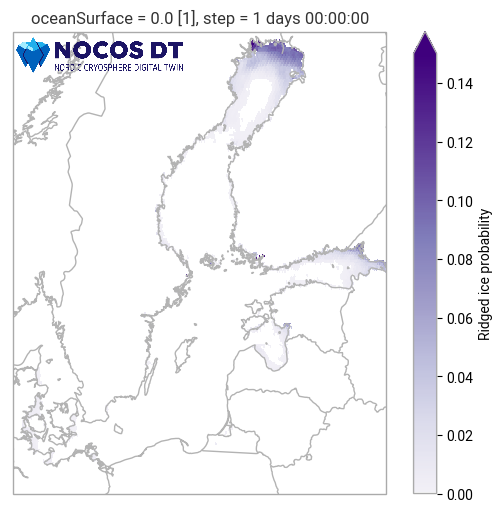

In [18]:

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
from datetime import datetime


# Define the variables for the selection
lon1, lon2 = 9, 30  # Longitude range
lat1, lat2 = 53, 66  # Latitude range
start_date = "2020-11-01"  # Start date
end_date = "2029-05-31"  # End date

# Select the data using the variables
ds_t_reg = ds.sel(
    **{"latitude": slice(lat1, lat2), "longitude": slice(lon1, lon2)}
).sel(time=slice(start_date, end_date))

# The rest of the code remains unchanged

# Apply the conditions for masking
# Ridging:  Thick ice  and has voids (0.3) due to porosity of ridges 
masked_data = ds_t_reg.where(
    (ds_t_reg.avg_sithick > 0.5) & 
    (ds_t_reg.avg_siconc > 0.975) & 
    (ds_t_reg.avg_siconc <= 0.999)
)
#masked_data = ds_t_reg.where(
#    (ds_t_reg.avg_sithick > 0.5) & 
#    (ds_t_reg.avg_siconc > 0.975) & 
#    (ds_t_reg.avg_siconc <= 0.3)
#)

# Calculate the number of days between the two dates
start = datetime.strptime(start_date, "%Y-%m-%d")
end = datetime.strptime(end_date, "%Y-%m-%d")
num_days = (end - start).days
# Count the number of days meeting the condition for each spatial point
rid_prob = masked_data.avg_siconc.count(dim="time")/num_days

# Create the plot
ax = plt.axes(projection=ccrs.Mercator())
ax.coastlines(color=(0.7, 0.7, 0.7))
ax.add_feature(cf.BORDERS,color=(0.7, 0.7, 0.7))

rid_prob.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=new_cmap, vmax=0.15,
    cbar_kwargs={"label": "Ridged ice probability"} 
)

# Set plot extent and features
#ax.set_extent([22, 26, 57, 60], crs=ccrs.PlateCarree())
#plt.title(" P (avg_sithick > 0.5 and 0.975 < avg_siconc <= 0.999)")

from matplotlib.offsetbox import OffsetImage, AnnotationBbox
# Load the logo and place it in the lower left corner
logo_path = f"{NOCOSDIR}/logos/NOCOS-DT_logo_RGB_fullcolour.png"
logo = plt.imread(logo_path)
imagebox = OffsetImage(logo, zoom=0.08)  # Adjust zoom for size
ab = AnnotationBbox(imagebox, (0.23, 0.95), frameon=False, xycoords="axes fraction")
ax.add_artist(ab)
# Show the plot
plt.show()

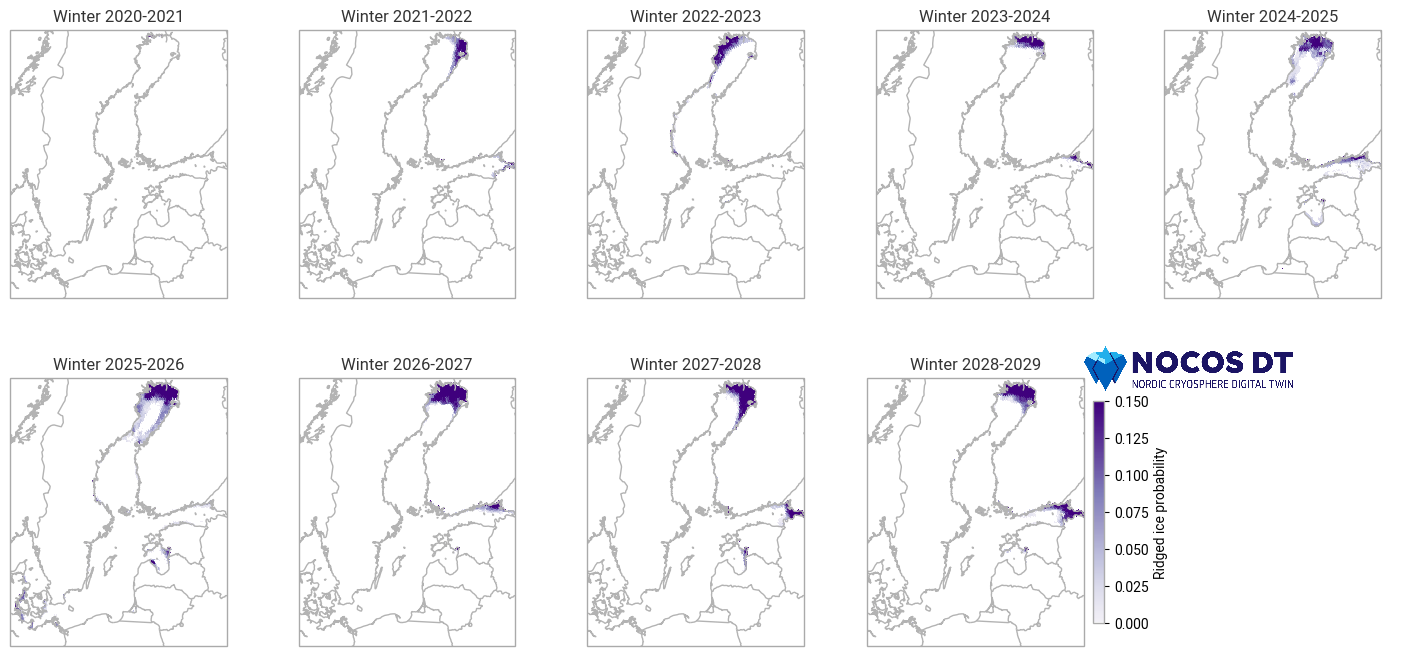

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
from datetime import datetime
import xarray as xr
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Define the variables for the selection
lon1, lon2 = 9, 30  # Longitude range
lat1, lat2 = 53, 66  # Latitude range
start_month, start_day = 11, 1  # Winter start date (Nov 1)
end_month, end_day = 5, 31  # Winter end date (May 31)

years = range(2020, 2029)  # Loop over years

# Define a custom colormap
original_cmap = plt.cm.Purples
colors = original_cmap(np.linspace(0.1, 1.0, 256))  # Exclude the first 10% of the colormap
colors[0] = [1, 1, 1, 1]  # Set the last color to white (RGBA)
new_cmap = ListedColormap(colors)

# Create a 2x5 subplot figure
fig, axs = plt.subplots(2, 5, figsize=(18, 8), subplot_kw={'projection': ccrs.Mercator()}, gridspec_kw={"wspace": 0.2, "hspace": 0.3})
axs = axs.flatten()

# Switch variable to toggle masking conditions
masking_option = 1  # Set to 1, 2, or 3 to choose masking condition

# Store the colorbar to add it only to the last subplot
colorbar = None

for idx, year in enumerate(years):
    # Define the winter start and end dates for each year
    start_date = f"{year}-{start_month:02d}-{start_day:02d}"
    end_date = f"{year + 1}-{end_month:02d}-{end_day:02d}"

    # Select the data using the variables
    ds_t_reg = ds.sel(
        **{"latitude": slice(lat1, lat2), "longitude": slice(lon1, lon2)}
    ).sel(time=slice(start_date, end_date))

    # Apply the conditions for masking based on the masking option
    if masking_option == 1:
        vm=0.15;clab="Ridged ice probability"
        masked_data = ds_t_reg.where(
            (ds_t_reg.avg_sithick > 0.5) &   # thick ice  
            (ds_t_reg.avg_siconc > 0.975) &  # porosity
            (ds_t_reg.avg_siconc <= 0.999)   # porosity  
        )
    elif masking_option == 2:
        vm=0.05;clab="Rotten ice probability"
        masked_data = ds_t_reg.where(
            (ds_t_reg.avg_sithick > 0.5) & 
            (ds_t_reg.avg_siconc <= 0.3)  # 
        )
    elif masking_option == 3:
        vm=0.7;clab="Ice probability"
        masked_data = ds_t_reg.where(
            (ds_t_reg.avg_siconc > 0.15)  # ICe detection threshold
        )

    # Calculate the number of days in the winter period
    start = datetime.strptime(start_date, "%Y-%m-%d")
    end = datetime.strptime(end_date, "%Y-%m-%d")
    num_days = (end - start).days

    # Calculate ridged ice probability
    rid_prob = masked_data.avg_siconc.count(dim="time") / num_days

    # Create the plot in the corresponding subplot
    ax = axs[idx]
    im = rid_prob.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=new_cmap, vmax=vm,
        add_colorbar=False
    )

    # Add the colorbar only to the last subplot
    if idx == len(years) - 1:
        colorbar = fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
        colorbar.set_label(clab)
 # Add the colorbar only to the last subplot
    # Set plot extent and features
    ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
    ax.coastlines(color=(0.7, 0.7, 0.7))
    ax.add_feature(cf.BORDERS, color=(0.7, 0.7, 0.7))

    # Set title with the year range
    ax.set_title(f"Winter {year}-{year + 1}")

# Add the logo to the last subplot
ax = axs[idx+1]
logo_path = f"{NOCOSDIR}/logos/NOCOS-DT_logo_RGB_fullcolour.png"
logo = plt.imread(logo_path)
imagebox = OffsetImage(logo, zoom=0.1)  # Adjust zoom for size
ab = AnnotationBbox(imagebox, (0.15, 1.2), frameon=False, xycoords="axes fraction")
ax.add_artist(ab)
# Remove borders (spines)
for spine in ax.spines.values():
    spine.set_visible(False)

# Optional: Customize ticks or labels if needed
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

## Example data (optional)
#ax.plot([1, 2, 3], [4, 5, 6])

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


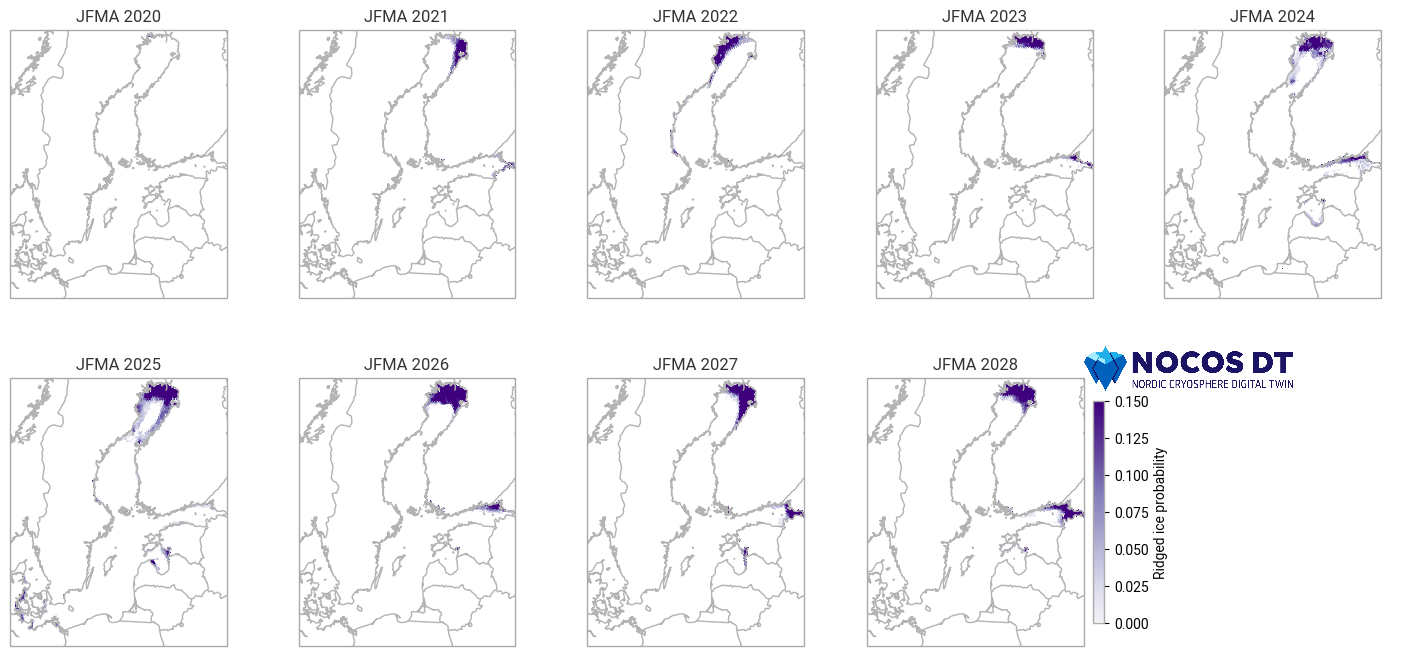

In [24]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
from datetime import datetime
import xarray as xr
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Define the variables for the selection
lon1, lon2 = 9, 30  # Longitude range
lat1, lat2 = 53, 66  # Latitude range

years = range(2020, 2029)  # Loop over years

# Define a custom colormap
original_cmap = plt.cm.Purples
colors = original_cmap(np.linspace(0.1, 1.0, 256))
colors[0] = [1, 1, 1, 1]
new_cmap = ListedColormap(colors)

# Create a 2x5 subplot figure
fig, axs = plt.subplots(2, 5, figsize=(18, 8), subplot_kw={'projection': ccrs.Mercator()}, gridspec_kw={"wspace": 0.2, "hspace": 0.3})
axs = axs.flatten()

masking_option = 1  # Select your condition as before

colorbar = None

for idx, year in enumerate(years):
    # Select data for JFMA months of each year
    start_date = f"{year}-01-01"
    end_date = f"{year}-04-30"

    ds_t_reg = ds.sel(
        latitude=slice(lat1, lat2),
        longitude=slice(lon1, lon2),
        time=slice(start_date, end_date)
    )

    # Apply JFMA month filter (to be extra safe if time axis has extra months)
    ds_t_reg = ds_t_reg.sel(time=ds_t_reg['time.month'].isin([1, 2, 3, 4]))

    # Apply the conditions for masking based on the masking option
    if masking_option == 1:
        vm = 0.15; clab = "Ridged ice probability"
        masked_data = ds_t_reg.where(
            (ds_t_reg.avg_sithick > 0.5) & 
            (ds_t_reg.avg_siconc > 0.975) &  
            (ds_t_reg.avg_siconc <= 0.999)
        )
    elif masking_option == 2:
        vm = 0.05; clab = "Rotten ice probability"
        masked_data = ds_t_reg.where(
            (ds_t_reg.avg_sithick > 0.5) & 
            (ds_t_reg.avg_siconc <= 0.3)
        )
    elif masking_option == 3:
        vm = 0.7; clab = "Ice probability"
        masked_data = ds_t_reg.where(
            (ds_t_reg.avg_siconc > 0.15)
        )

    # Calculate the number of days in the selected period
    num_days = masked_data.time.size

    # Calculate ridged ice probability
    rid_prob = masked_data.avg_siconc.count(dim="time") / num_days

    # Create the plot in the corresponding subplot
    ax = axs[idx]
    im = rid_prob.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=new_cmap, vmax=vm,
        add_colorbar=False
    )

    if idx == len(years) - 1:
        colorbar = fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
        colorbar.set_label(clab)

    ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
    ax.coastlines(color=(0.7, 0.7, 0.7))
    ax.add_feature(cf.BORDERS, color=(0.7, 0.7, 0.7))
    ax.set_title(f"JFMA {year}")

# Add the logo to the last subplot
ax = axs[idx+1]
logo_path = f"{NOCOSDIR}/logos/NOCOS-DT_logo_RGB_fullcolour.png"
logo = plt.imread(logo_path)
imagebox = OffsetImage(logo, zoom=0.1)
ab = AnnotationBbox(imagebox, (0.15, 1.2), frameon=False, xycoords="axes fraction")
ax.add_artist(ab)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

plt.tight_layout()
plt.show()


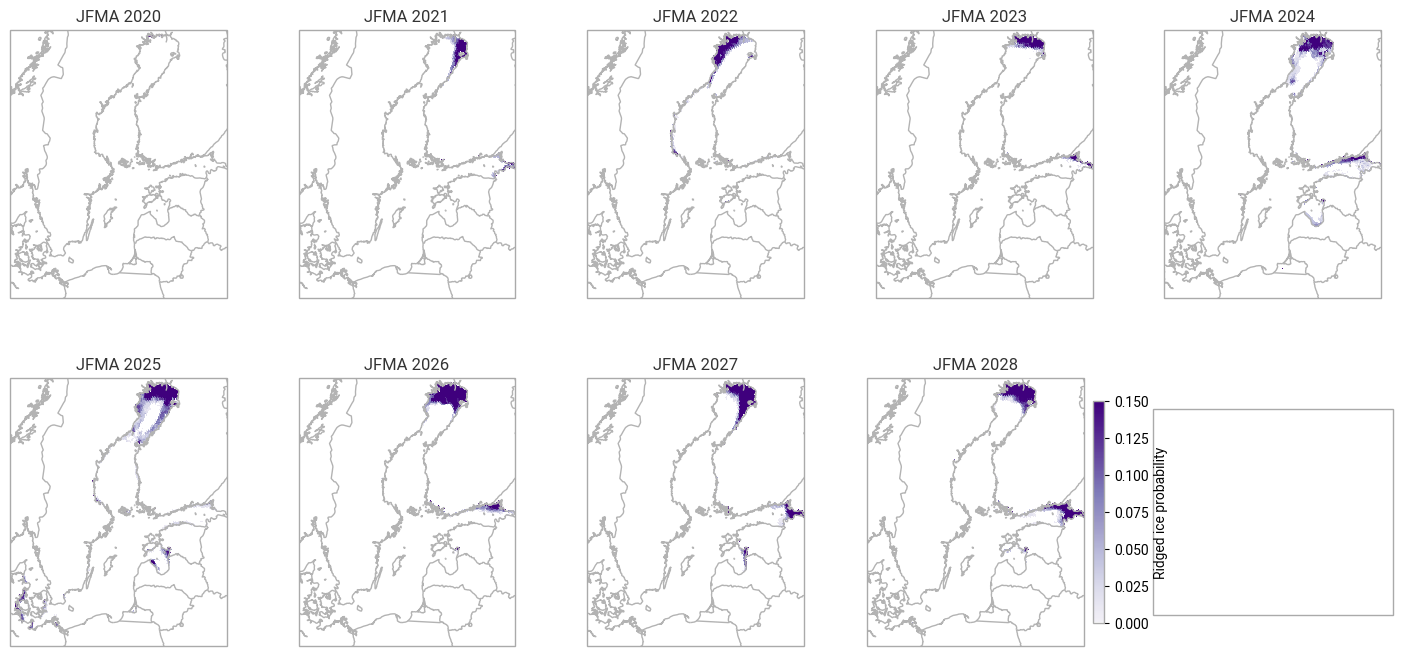

In [4]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
from datetime import datetime
import xarray as xr
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Define the variables for the selection
lon1, lon2 = 9, 30  # Longitude range
lat1, lat2 = 53, 66  # Latitude range

years = range(2020, 2029)  # Loop over years

# Define a custom colormap
original_cmap = plt.cm.Purples
colors = original_cmap(np.linspace(0.1, 1.0, 256))
colors[0] = [1, 1, 1, 1]
new_cmap = ListedColormap(colors)

# Create a 2x5 subplot figure
fig, axs = plt.subplots(2, 5, figsize=(18, 8), subplot_kw={'projection': ccrs.Mercator()}, gridspec_kw={"wspace": 0.2, "hspace": 0.3})
axs = axs.flatten()

masking_option = 1  # Select your condition as before

colorbar = None

# Prepare list to collect yearly rid_prob fields
rid_prob_list = []

for idx, year in enumerate(years):
    # Select data for JFMA months of each year
    start_date = f"{year}-01-01"
    end_date = f"{year}-04-30"

    ds_t_reg = ds.sel(
        latitude=slice(lat1, lat2),
        longitude=slice(lon1, lon2),
        time=slice(start_date, end_date)
    )

    ds_t_reg = ds_t_reg.sel(time=ds_t_reg['time.month'].isin([1, 2, 3, 4]))

    # Apply the conditions for masking based on the masking option
    if masking_option == 1:
        vm = 0.15; clab = "Ridged ice probability"
        masked_data = ds_t_reg.where(
            (ds_t_reg.avg_sithick > 0.5) & 
            (ds_t_reg.avg_siconc > 0.975) &  
            (ds_t_reg.avg_siconc <= 0.999)
        )
    elif masking_option == 2:
        vm = 0.05; clab = "Rotten ice probability"
        masked_data = ds_t_reg.where(
            (ds_t_reg.avg_sithick > 0.5) & 
            (ds_t_reg.avg_siconc <= 0.3)
        )
    elif masking_option == 3:
        vm = 0.7; clab = "Ice probability"
        masked_data = ds_t_reg.where(
            (ds_t_reg.avg_siconc > 0.15)
        )

    num_days = masked_data.time.size

    rid_prob = masked_data.avg_siconc.count(dim="time") / num_days

    # Store yearly result
    rid_prob_list.append(rid_prob)

    # Plot each year
    ax = axs[idx]
    im = rid_prob.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=new_cmap, vmax=vm,
        add_colorbar=False
    )

    if idx == len(years) - 1:
        colorbar = fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
        colorbar.set_label(clab)

    ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
    ax.coastlines(color=(0.7, 0.7, 0.7))
    ax.add_feature(cf.BORDERS, color=(0.7, 0.7, 0.7))
    ax.set_title(f"JFMA {year}")

# -------------------------------
# After loop: compute multi-year mean
# -------------------------------

# Stack into xarray
stacked = xr.concat(rid_prob_list, dim='year')
mean_rid_prob = stacked.mean(dim='year')


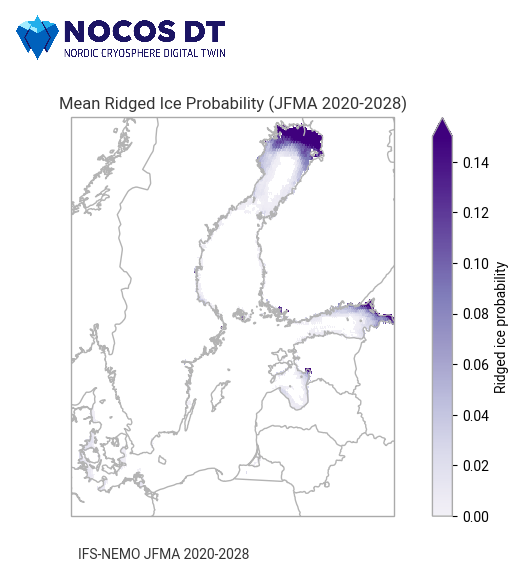

In [5]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
from matplotlib.colors import ListedColormap
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np
#!pip install cmocean
#import cmocean
#new_cmap = cmocean.cm.ice_r


fig, ax = plt.subplots(1, 1, figsize=(8, 6), subplot_kw={'projection': ccrs.Mercator()})

im = mean_rid_prob.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=new_cmap, vmax=vm,
    cbar_kwargs={'label': clab}
)

ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
ax.coastlines(color=(0.7, 0.7, 0.7))
ax.add_feature(cf.BORDERS, color=(0.7, 0.7, 0.7))

# Title
ax.set_title(f"Mean Ridged Ice Probability (JFMA {years.start}-{years.stop-1})")

# Add annotation box
annotation_text = f"IFS-NEMO JFMA {years.start}-{years.stop-1}"
ax.text(0.02, -0.08, annotation_text, transform=ax.transAxes, fontsize=10, ha='left', va='top')

# Add NOCOS logo
logo_path = f"{NOCOSDIR}/logos/NOCOS-DT_logo_RGB_fullcolour.png"
logo = plt.imread(logo_path)
imagebox = OffsetImage(logo, zoom=0.1)
ab = AnnotationBbox(imagebox, (0.15, 1.2), frameon=False, xycoords="axes fraction")
ax.add_artist(ab)

plt.tight_layout()
plt.show()


In [6]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Define custom color gradient
colors = [
    (1.0, 1.0, 1.0),   # pure white for zero
    (0.85, 0.92, 1.0), # light blue
    (0.6, 0.7, 1.0),   # medium blue
    (0.5, 0.3, 0.8),   # violet
    (0.4, 0.1, 0.5),   # strong purple
]

# Apply non-linear scaling for low value boost
N = 256
stretch = np.linspace(0, 1, N)**0.5  # square root stretch
stretched_colors = [LinearSegmentedColormap.from_list("custom_ridged", colors)(s) for s in stretch]
new_cmap = LinearSegmentedColormap.from_list("custom_ridged_boosted", stretched_colors, N=N)


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

# Dummy: area per grid cell (you may replace with exact area calculation if available)
# For example ~12.3 km^2 per 0.1 degree cell at 60°N as a rough estimate
# Better: precompute from lat/lon spacing
grid_cell_area_km2 = 23.8  # <-- adjust depending on your resolution

years = range(2020, 2029)

annual_max_extent = []

for year in years:
    # Select JFMA for given year
    start_date = f"{year}-11-01"
    end_date = f"{year+1}-04-30"

    ds_t_reg = ds.sel(
        latitude=slice(lat1, lat2),
        longitude=slice(lon1, lon2),
        time=slice(start_date, end_date)
    )

    ds_t_reg = ds_t_reg.sel(time=ds_t_reg['time.month'].isin([1, 2, 3, 4]))

    # Apply ridged ice mask
    masked_data = ds_t_reg.where(
        (ds_t_reg.avg_sithick > 0.5) & 
        (ds_t_reg.avg_siconc > 0.975) &  
        (ds_t_reg.avg_siconc <= 0.999)
    )

    # For each timestep calculate total ridged ice area
    daily_extent = masked_data.avg_siconc.notnull().sum(dim=["latitude", "longitude"]) * grid_cell_area_km2

    # Extract maximum extent for that year
    max_extent = daily_extent.max().compute().item()
    annual_max_extent.append(max_extent)

# Convert to numpy array for convenience
annual_max_extent = np.array(annual_max_extent)




In [47]:
ds

,Array,Chunk
Bytes,456.68 GiB,15.00 MiB
Shape,"(3653, 4096, 8193)","(60, 256, 256)"
Count,32209 Tasks,32208 Chunks
Type,float32,numpy.ndarray
,Array,Chunk
Bytes,456.68 GiB,15.00 MiB
Shape,"(3653, 4096, 8193)","(60, 256, 256)"
Count,32209 Tasks,32208 Chunks
Type,float32,numpy.ndarray
,Array,Chunk


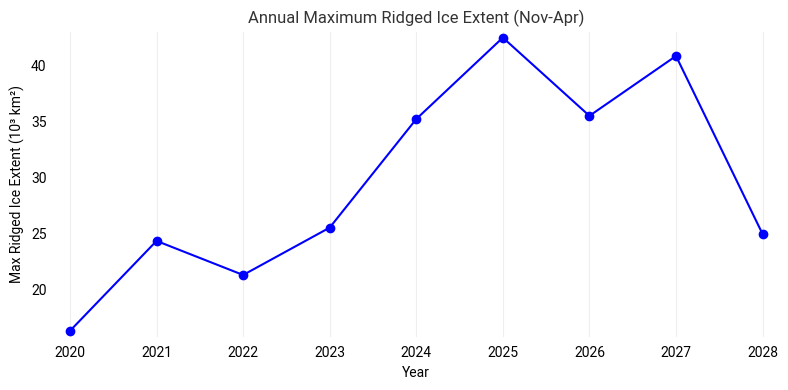

In [46]:
# ---- Plot ----

plt.figure(figsize=(8,4))
plt.plot(list(years), annual_max_extent*1e-3, marker='o', color='b')
plt.grid()
plt.xlabel("Year")
plt.ylabel("Max Ridged Ice Extent (10³ km²)")
plt.title("Annual Maximum Ridged Ice Extent (Nov-Apr)")
plt.tight_layout()
plt.show()

In [8]:
import numpy as np
# Estimate longitude and latitude step size
lon = ds["longitude"]
lat = ds["latitude"]

# Assuming regular grid, take difference between first two points
d_lon = abs(lon[1] - lon[0]).item()
d_lat = abs(lat[1] - lat[0]).item()

print(f"Grid resolution: {d_lon} deg lon x {d_lat} deg lat")
# Mean latitude (midpoint)
lat_mid = lat.mean().item()
earth_radius_km = 6371.0  # Earth radius in km

# Convert degrees to radians
d_lat_rad = np.deg2rad(d_lat)
d_lon_rad = np.deg2rad(d_lon)
lat_mid_rad = np.deg2rad(lat_mid)

# Estimate grid cell area (in km²)
cell_area_km2 = (earth_radius_km**2) * d_lat_rad * d_lon_rad * np.cos(lat_mid_rad)

print(f"Estimated grid cell area: {cell_area_km2:.2f} km²")

Grid resolution: 0.0439453125 deg lon x 0.0439560439560438 deg lat
Estimated grid cell area: 23.88 km²


In [9]:
annual_max_extent = []
annual_mean_drift = []
annual_strong_drift_area = []

for year in years:
    # Select JFMA for given year
    start_date = f"{year}-11-01"
    end_date = f"{year+1}-04-30"

    ds_t_reg = ds.sel(
        latitude=slice(lat1, lat2),
        longitude=slice(lon1, lon2),
        time=slice(start_date, end_date)
    )

    ds_t_reg = ds_t_reg.sel(time=ds_t_reg['time.month'].isin([1, 2, 3, 4]))

    # --- Ridged ice extent calculation ---
    masked_data = ds_t_reg.where(
        (ds_t_reg.avg_sithick > 0.5) & 
        (ds_t_reg.avg_siconc > 0.975) &  
        (ds_t_reg.avg_siconc <= 0.999)
    )

    daily_extent = masked_data.avg_siconc.notnull().sum(dim=["latitude", "longitude"]) * grid_cell_area_km2
    max_extent = daily_extent.max().compute().item()
    annual_max_extent.append(max_extent)

    # --- Ice drift velocity calculation with thickness mask ---
    thickness_mask = ds_t_reg.avg_sithick > 0.5
    siue_masked = ds_t_reg.avg_siue.where(thickness_mask)
    sivn_masked = ds_t_reg.avg_sivn.where(thickness_mask)

    drift_speed = np.sqrt(siue_masked**2 + sivn_masked**2)
    mean_drift = drift_speed.mean().compute().item()
    annual_mean_drift.append(mean_drift)

    # --- Strong drift area calculation ---
    strong_drift_mask = drift_speed > 0.1  # m/s threshold
    daily_strong_area = strong_drift_mask.sum(dim=["latitude", "longitude"]) * grid_cell_area_km2
    mean_strong_area = daily_strong_area.mean().compute().item()  # mean area over JFMA
    annual_strong_drift_area.append(mean_strong_area)

# Convert extent to 10³ km²
annual_max_extent = np.array(annual_max_extent) * 1e-3
annual_strong_drift_area = np.array(annual_strong_drift_area) * 1e-3



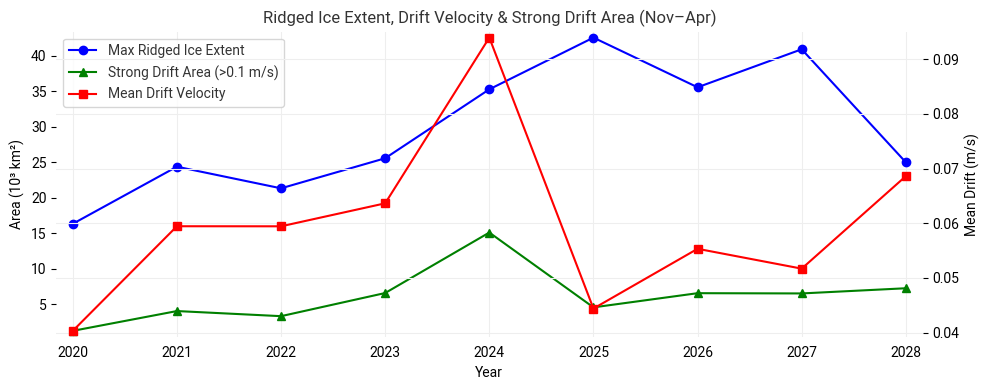

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

# Create the first axis
ax1 = plt.gca()

# Plot extent and strong drift area on primary y-axis
ln1 = ax1.plot(list(years), annual_max_extent, marker='o', color='b', label='Max Ridged Ice Extent')
ln2 = ax1.plot(list(years), annual_strong_drift_area, marker='^', color='g', label='Strong Drift Area (>0.1 m/s)')

ax1.set_xlabel("Year")
ax1.set_ylabel("Area (10³ km²)", color='black')
ax1.grid()

# Create the second axis for drift velocity
ax2 = ax1.twinx()
ln3 = ax2.plot(list(years), annual_mean_drift, marker='s', color='r', label='Mean Drift Velocity')
ax2.set_ylabel("Mean Drift (m/s)", color='black')

# Combine legends
lines = ln1 + ln2 + ln3
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title("Ridged Ice Extent, Drift Velocity & Strong Drift Area (Nov–Apr)")
plt.tight_layout()
plt.show()



In [11]:
import xarray as xr

url_sfc = "https://cacheb.dcms.destine.eu/d1-climate-dt/ScenarioMIP-SSP3-7.0-IFS-NEMO-0001-high-sfc-v0.zarr"

ds_sfc = xr.open_dataset(
    url_sfc, 
    engine="zarr", 
    consolidated=True,
    chunks={},
    storage_options={"client_kwargs": {"trust_env": True}}
)


/tmp/ipykernel_1722/3669501855.py:5: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_sfc = xr.open_dataset(


In [14]:
# Define the variables for the selection
lon1, lon2 = 9, 30  # Longitude range
lat1, lat2 = 53, 66  # Latitude range
start_date = "2020-11-01"  # Start date
end_date = "2029-05-31"  # End date

# Select the data using the same structure
ds_sfc_reg = ds_sfc.sel(
    **{"latitude": slice(lat1, lat2), "longitude": slice(lon1, lon2)}
).sel(time=slice(start_date, end_date))


In [15]:
annual_mean_t2m = []
annual_mean_wind = []

for year in years:
    # Select Nov–Apr for given year
    start_date = f"{year}-11-01"
    end_date = f"{year+1}-04-30"

    ds_sfc_reg = ds_sfc.sel(
        latitude=slice(lat1, lat2),
        longitude=slice(lon1, lon2),
        time=slice(start_date, end_date)
    )

    # Select only months 11-12 + 1-2-3-4 to stay fully consistent
    ds_sfc_reg = ds_sfc_reg.sel(time=ds_sfc_reg['time.month'].isin([11, 12, 1, 2, 3, 4]))

    # --- 2m temperature (K -> °C) ---
    t2m_mean_area = (ds_sfc_reg['t2m'].mean(dim="time") - 273.15).mean(dim=["latitude", "longitude"])
    t2m_mean_value = t2m_mean_area.compute().item()
    annual_mean_t2m.append(t2m_mean_value)

    # --- Wind speed ---
    wind_speed = np.sqrt(ds_sfc_reg['u10']**2 + ds_sfc_reg['v10']**2)
    wind_mean_area = wind_speed.mean(dim="time").mean(dim=["latitude", "longitude"])
    wind_mean_value = wind_mean_area.compute().item()
    annual_mean_wind.append(wind_mean_value)


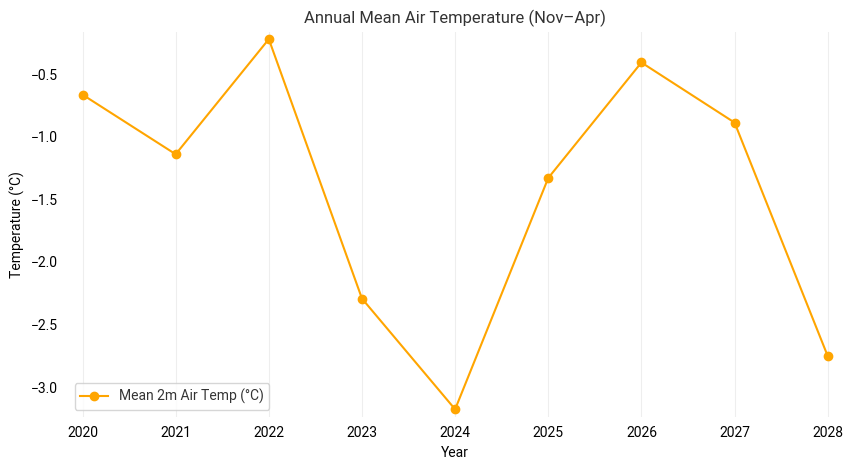

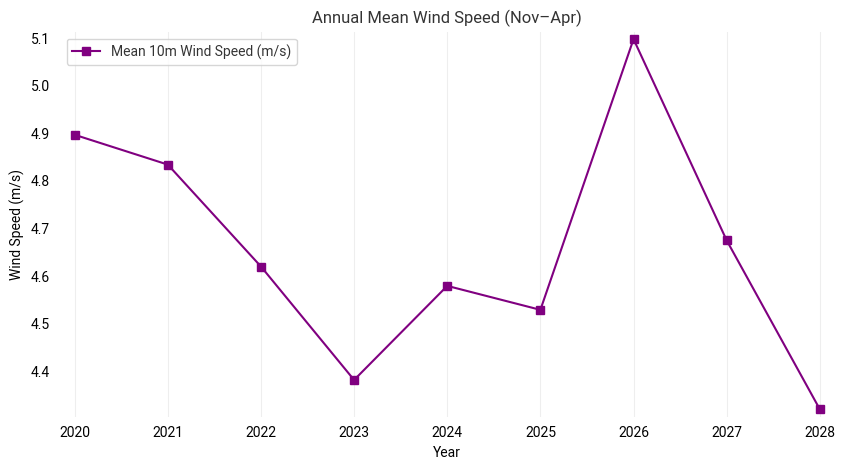

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(list(years), annual_mean_t2m, marker='o', color='orange', label='Mean 2m Air Temp (°C)')
plt.ylabel("Temperature (°C)")
plt.xlabel("Year")
plt.title("Annual Mean Air Temperature (Nov–Apr)")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(list(years), annual_mean_wind, marker='s', color='purple', label='Mean 10m Wind Speed (m/s)')
plt.ylabel("Wind Speed (m/s)")
plt.xlabel("Year")
plt.title("Annual Mean Wind Speed (Nov–Apr)")
plt.grid()
plt.legend()
plt.show()


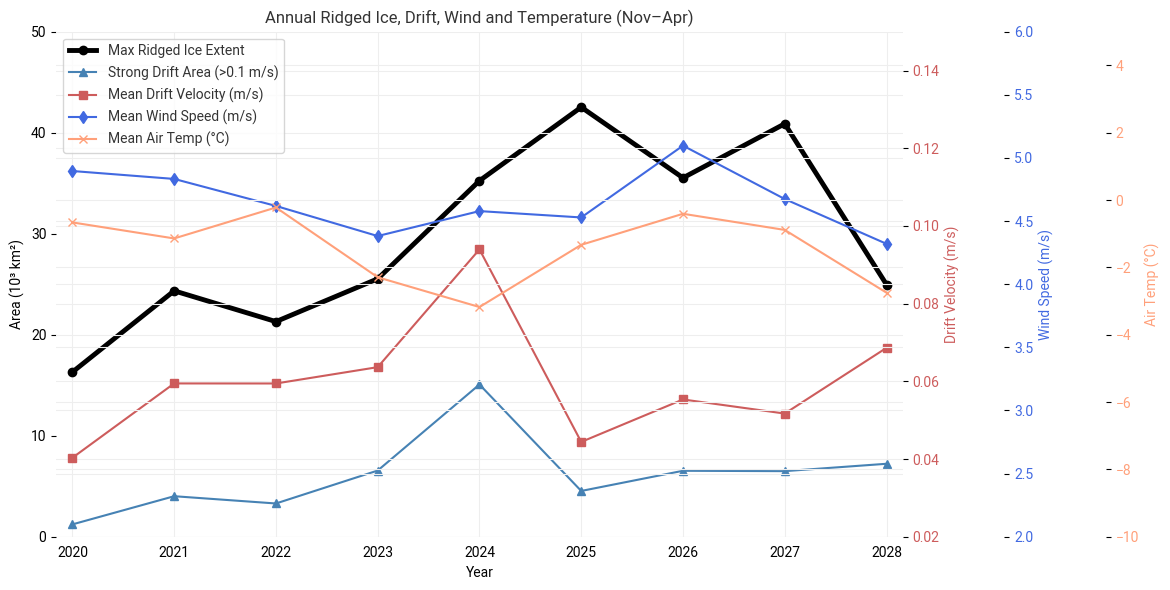

In [29]:
import matplotlib.pyplot as plt

# Updated limits
area_ylim = (0, 50)       # Area (10³ km²)
drift_ylim = (0.02, 0.15) # Drift velocity (m/s)
wind_ylim  = (2, 6)       # Wind speed (m/s)
temp_ylim  = (-10, 5)     # Air temperature (°C)

# Define slightly darker colors
color_extent = 'black'
color_strong_drift_area = '#4682B4'  # steel blue
color_drift = '#CD5C5C'  # indian red
color_wind = '#4169E1'   # royal blue
color_temp = '#FFA07A'   # light salmon

fig, ax1 = plt.subplots(figsize=(12, 6))

# Axis 1 (left): areas
ln1 = ax1.plot(list(years), annual_max_extent, marker='o', color=color_extent, linewidth=3.5, label='Max Ridged Ice Extent')
ln2 = ax1.plot(list(years), annual_strong_drift_area, marker='^', color=color_strong_drift_area, label='Strong Drift Area (>0.1 m/s)')
ax1.set_xlabel("Year")
ax1.set_ylabel("Area (10³ km²)", color=color_extent)
ax1.set_ylim(area_ylim)
ax1.tick_params(axis='y', labelcolor=color_extent)
ax1.grid()

# Axis 2 (right): drift velocity
ax2 = ax1.twinx()
ln3 = ax2.plot(list(years), annual_mean_drift, marker='s', color=color_drift, label='Mean Drift Velocity (m/s)')
ax2.set_ylabel("Drift Velocity (m/s)", color=color_drift)
ax2.set_ylim(drift_ylim)
ax2.tick_params(axis='y', labelcolor=color_drift)

# Axis 3 (right): wind speed (offset right)
ax3 = ax1.twinx()
ax3.spines.right.set_position(("axes", 1.12))
ln4 = ax3.plot(list(years), annual_mean_wind, marker='d', color=color_wind, label='Mean Wind Speed (m/s)')
ax3.set_ylabel("Wind Speed (m/s)", color=color_wind)
ax3.set_ylim(wind_ylim)
ax3.tick_params(axis='y', labelcolor=color_wind)

# Axis 4 (right): air temperature
ax4 = ax1.twinx()
ax4.spines.right.set_position(("axes", 1.24))
ln5 = ax4.plot(list(years), annual_mean_t2m, marker='x', color=color_temp, label='Mean Air Temp (°C)')
ax4.set_ylabel("Air Temp (°C)", color=color_temp)
ax4.set_ylim(temp_ylim)
ax4.tick_params(axis='y', labelcolor=color_temp)

# Combine all lines for legend
lines = ln1 + ln2 + ln3 + ln4 + ln5
labels = [l.get_label() for l in lines]
ax4.legend(lines, labels, loc='upper left')

plt.title("Annual Ridged Ice, Drift, Wind and Temperature (Nov–Apr)")
plt.tight_layout()
plt.show()
